In [44]:
#  Ebnable HTML/CSS 
from IPython.core.display import HTML
HTML("<link href='https://fonts.googleapis.com/css?family=Passion+One' rel='stylesheet' type='text/css'><style>div.attn { font-family: 'Helvetica Neue'; font-size: 30px; line-height: 40px; color: #FFFFFF; text-align: center; margin: 30px 0; border-width: 10px 0; border-style: solid; border-color: #5AAAAA; padding: 30px 0; background-color: #DDDDFF; }hr { border: 0; background-color: #ffffff; border-top: 1px solid black; }hr.major { border-top: 10px solid #5AAA5A; }hr.minor { border: none; background-color: #ffffff; border-top: 5px dotted #CC3333; }div.bubble { width: 65%; padding: 20px; background: #DDDDDD; border-radius: 15px; margin: 0 auto; font-style: italic; color: #f00; }em { color: #AAA; }div.c1{visibility:hidden;margin:0;height:0;}div.note{color:red;}</style>")

___
Enter Your Name here, assignment should be completed individually (*double click to edit*):

- Your Name: Yash Shah

___

# In Class Assignment Three
In the following assignment you will be asked to fill in python code and derivations for a number of different problems. Please read all instructions carefully and turn in the rendered notebook (or HTML of the rendered notebook)  before the end of class (or right after class). The initial portion of this notebook is given before class and the remainder is given during class. Please answer the initial questions before class, to the best of your ability. Once class has started you may rework your answers as a team for the initial part of the assignment. 

<a id="top"></a>
## Contents
* <a href="#LoadingKDD">Loading KDDCup Data</a>
* <a href="#kdd_eval">KDDCup Evaluation and Cross Validation</a>
* <a href="#data_snooping">More Cross Validation</a>
* <a href="#stats">Statistical Comparison</a>

**Before coming to class**, please make sure you have the latest version of `scikit-learn`. This notebook was created for version 0.18 and higher. 

________________________________________________________________________________________________________

<a id="LoadingKDD"></a>
<a href="#top">Back to Top</a>
## Loading KDDCup Data

Please run the following code to read in the "KDD Cup" dataset from sklearn's data loading module. It consists of examples of different simulated attacks for the 1998 DARPA Intrusion Detection System (IDS). 

This will load the data into the variable `ds`. `ds` is a `bunch` object with fields like `ds.data` and `ds.target`. The field `ds.data` is a numpy matrix of the continuous features in the dataset. **The object is not a pandas dataframe. It is a numpy matrix.** Each row is a set of observed instances, each column is a different feature. It also has a field called `ds.target` that is an integer value we are trying to predict (i.e., a specific integer represents a specific person). Each entry in `ds.target` is a label for each row of the `ds.data` matrix. 

In [45]:
# fetch the dataset
from sklearn.datasets import fetch_kddcup99
from sklearn import __version__ as sklearn_version

print('Sklearn Version:',sklearn_version)
ds =  fetch_kddcup99(subset='http')

Sklearn Version: 1.7.2


___
**Question 1:** How many instances are in the binary classification problem loaded above? How many instances are in each class? **Plot a pie chart or bar chart of the number of instances in each of the classes.**

Number of instances in each class: [56516  2209]
Total instances: 58725
Class 0 (normal): 56516
Class 1 (attack): 2209


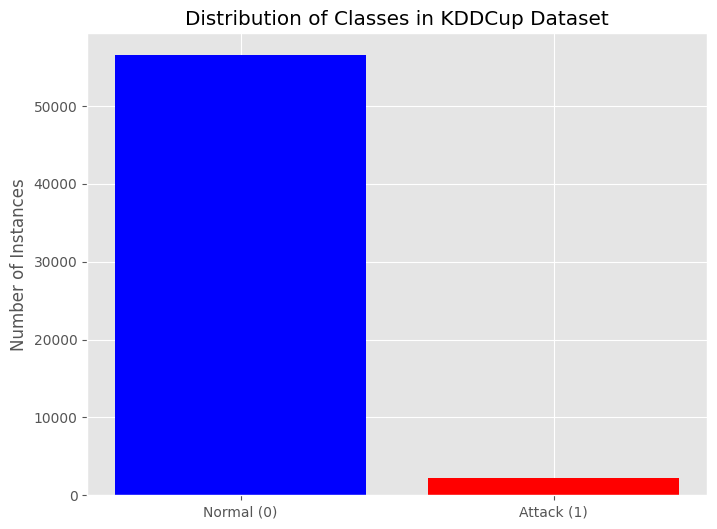

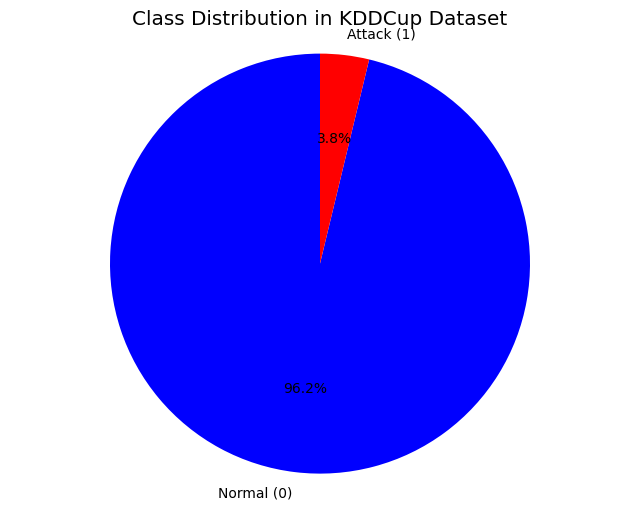

In [55]:
from matplotlib import pyplot as plt
%matplotlib inline
plt.style.use('ggplot')


#=== Fill in code below========
class_counts = np.bincount(y)
print(f'Number of instances in each class: {class_counts}')
print(f'Total instances: {len(y)}')
print(f'Class 0 (normal): {class_counts[0]}')
print(f'Class 1 (attack): {class_counts[1]}')

# Plot bar chart
plt.figure(figsize=(8, 6))
plt.bar(['Normal (0)', 'Attack (1)'], class_counts, color=['blue', 'red'])
plt.ylabel('Number of Instances')
plt.title('Distribution of Classes in KDDCup Dataset')
plt.show()

# Plot pie chart
plt.figure(figsize=(8, 6))
plt.pie(class_counts, labels=['Normal (0)', 'Attack (1)'], autopct='%1.1f%%', startangle=90, colors=['blue', 'red'])
plt.title('Class Distribution in KDDCup Dataset')
plt.axis('equal')
plt.show()

<a id="kdd_eval"></a>
<a href="#top">Back to Top</a>
## KDDCup Evaluation and Cross Validation
Look at the following code that trains a model using 10-fold cross validation. You can also run this code to see the outputs. Then answer the question below it. 

You might also be interested in the following graphic: 
- https://en.wikipedia.org/wiki/Precision_and_recall#/media/File:Precisionrecall.svg

And the following:
$$ Precision = \frac{TP}{TP+FP} $$

and

$$ Recall = \frac{TP}{TP+FN} $$

and 

$$ F_1 = 2\cdot\frac{Precision\cdot Recall}{Precision + Recall} $$

and a new score that you might like to look at:

$$ F_{\beta} = (1+\beta^2)\cdot\frac{Precision\cdot Recall}{\beta^2\cdot Precision + Recall} $$

(0.9894891008174387, 1.0)

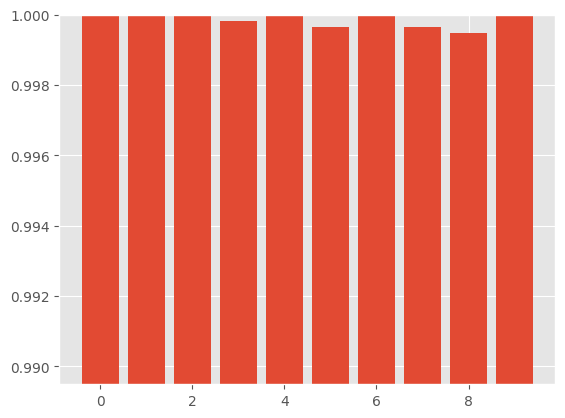

In [48]:
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import KFold, ShuffleSplit
from sklearn.model_selection import StratifiedKFold, StratifiedShuffleSplit

from sklearn.metrics import make_scorer, accuracy_score
from sklearn.metrics import precision_score, recall_score, f1_score

from sklearn.linear_model import LogisticRegression

# select model
clf = LogisticRegression()
#select cross validation
cv = KFold(n_splits=10)
# select evaluation criteria
my_scorer = make_scorer(accuracy_score)
# run model training and cross validation
per_fold_eval_criteria = cross_val_score(estimator=clf,
                                    X=X,
                                    y=y,
                                    cv=cv,
                                    scoring=my_scorer
                                   )
plt.bar(range(len(per_fold_eval_criteria)),per_fold_eval_criteria)
plt.ylim([min(per_fold_eval_criteria)-0.01,max(per_fold_eval_criteria)])

____
**Question 2** Is the code above a proper separation of training and testing sets for the given dataset (i.e., using KFold)? Why or why not? 



*Enter your answer here (double click)*

*Yes or No and why*

No, the dataset is imbalanced. Regula KFold does not preserve class proportions across folds, so some folds may have few or no examples of the minority class.
___

**Question 3:** Is the evaluation metric chosen in the above code appropriate for the dataset (i.e., using accuracy)? Why or Why not?

*Enter your answer here (double click)*

*Yes or No and why* 

No, with an imbalanced dataset, accuracy can be misleading. A classifier that always predicts the majority class can achieve a high accuracy while failing in the minority class.
___

**Exercise 1:** If the code above is not a proper separation of the train or does not use the proper evaluation criteria, fix the code in the block below to use appropriate train/test separation and appropriate evaluation criterion (criteria). **Mark changes in the code with comments.**

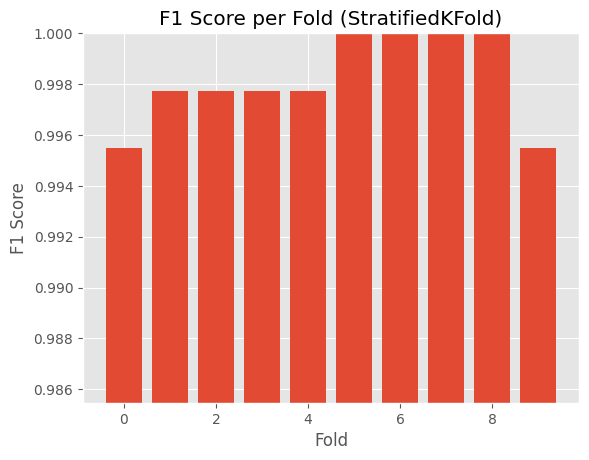

In [49]:
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import make_scorer, f1_score
from sklearn.linear_model import LogisticRegression

# FIXED: Use StratifiedKFold instead of KFold to maintain class distribution
# FIXED: Use F1-score instead of accuracy for imbalanced dataset
clf = LogisticRegression()
cv = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)  # CHANGED
my_scorer = make_scorer(f1_score)  # CHANGED

per_fold_eval_criteria = cross_val_score(estimator=clf,
                                    X=X,
                                    y=y,
                                    cv=cv,
                                    scoring=my_scorer
                                   )

plt.bar(range(len(per_fold_eval_criteria)),per_fold_eval_criteria)
plt.ylim([min(per_fold_eval_criteria)-0.01,max(per_fold_eval_criteria)])
plt.xlabel('Fold')
plt.ylabel('F1 Score')
plt.title('F1 Score per Fold (StratifiedKFold)')
plt.show()

____
**Question 4**: Does the learning algorithm perform well based on the evaluation criteria? Why or why not, based on the way the system will be used?


*Enter you answer here (double click to edit)*

 
Whether the algorithm performs well depends on the evaluation criteria and the deployment context. For an intrusion detection system, high recall is critical because missing an attack (false negative) is worse than flagging normal traffic as an attack (false positive). F1-score balances precision and recall, but equal weighting may not be ideal here. If F1 is high (e.g., > 0.9), the model is performing well overall. However, also check individual precision and recall: if precision is high but recall is low, the model misses attacks, which is unacceptable for security. Conversely, if recall is high but precision is moderate, that is often acceptable since investigating false alarms is preferable to missing real threats. For this use case, consider F-beta with beta > 1 to emphasize recall, or evaluate precision and recall separately to ensure the model meets security requirements. The performance should be judged not only by the aggregate metric, but by whether it reliably detects attacks while keeping false positive rates manageable for operational use.

___


<a id="data_snooping"></a>
<a href="#top">Back to Top</a>

## More Cross Validation

**Exercise 2:** Does the code below contain any errors in the implementation of the cross validation? If so, explain the errors in the space provided below and then fix the code below so that there are no longer any errors in the cross validation.


*Explain any cross validation errors here (double click to edit)*

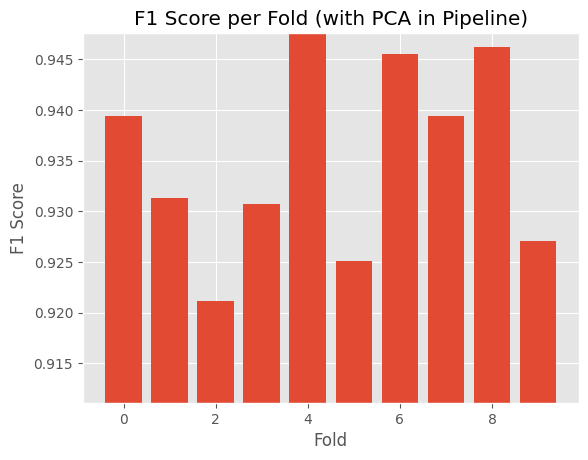

In [50]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline


#======If there are errors, fix them below======
# FIXED: PCA should be in the pipeline, not fit on entire dataset
# This prevents data leakage - PCA will be fit only on training data in each fold
n_components = 1

clf = Pipeline([('pca', PCA(n_components=n_components)),
                ('scl', StandardScaler()),
                ('clf', LogisticRegression())])

# FIXED: Use X instead of Xpca, and use StratifiedKFold with F1-score
cv = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)
my_scorer = make_scorer(f1_score)

per_fold_eval_criteria = cross_val_score(estimator=clf,
                                    X=X,
                                    y=y,
                                    cv=cv,
                                    scoring=my_scorer
                                   )

plt.bar(range(len(per_fold_eval_criteria)),per_fold_eval_criteria)
plt.ylim([min(per_fold_eval_criteria)-0.01,max(per_fold_eval_criteria)])
plt.xlabel('Fold')
plt.ylabel('F1 Score')
plt.title('F1 Score per Fold (with PCA in Pipeline)')
plt.show()

___

# Circumstances Change
For this question, the circumstances for the DARPA KDD99 cup are changed in the following way:
- When the model for detecting attacks is deployed, we now think that it will often need to be retrained because new attacks will emerge.
 - DARPA anticipates that there will be a handful of different style attacks on their systems that have never been seen before. To detect these new attacks, they are employing programmers and analysts to find them manually every day. 
 - DARPA believes the perpetrators of these new attacks are more sophisticated, so finding the new attacks will take priority over detecting the older, known attacks. 
- DARPA wants to use your learning algorithm for detecting only these new attacks. However, they tell you that the amount of training data for the new attacks will be extremely small. That is, the analysts can only identify a handful of new style attacks each day (so you will only have about 3-5 examples of the attacks for training).
- **DARPA asks you: Do you think its a good idea to employ retraining your model each day to find these new attacks?** They need an answer in the next 20 minutes.  

**Question 5**: How would you change the method of cross validation to answer this question from DARPA? That is, how can you change your cross validation method to better mirror how your system will be used and deployed by DARPA when there are only 3-5 attack examples available for training? *Note: you do not have access to these new training examples. You need to change you cross validation method with the existing data to answer this question.* 

*Enter your answer here (double click)*

*We could... and why*

To mirror the DARPA scenario with only 3–5 attack examples per day, we could use StratifiedShuffleSplit with a very small training size that yields roughly 3–5 positive examples. Since the class distribution is known, compute the training size so that the minority class percentage of that size equals 3–5. This approach maintains class distribution (stratified), uses random sampling (shuffle split) to simulate random discovery of new attacks, allows testing with very small training sets to assess learning from limited examples, and repeats many times to get a distribution of performance, showing reliability with limited data. This helps determine whether daily retraining with only 3–5 new attack examples is feasible or too unreliable. By running this cross-validation with the existing dataset, you can estimate performance variance and whether the model can learn effectively from such small samples, informing the decision on whether to proceed with daily retraining.
___

In [51]:
#plotting function for use in next question
# takes input 'test_scores', axis labels, and an x-axis label
def plot_filled(test_scores,train_x_axis, xlabel=''):
    
    test_mean = np.percentile(test_scores,50, axis=1)
    test_max = np.percentile(test_scores,95, axis=1) 
    test_min = np.percentile(test_scores,5, axis=1) 

    plt.plot(train_x_axis, test_mean,
             color='blue', linestyle='--',
             marker='s', markersize=5,
             label='validation set')

    plt.fill_between(train_x_axis,
                     test_min,
                     test_max,
                     alpha=0.15, color='blue')

    plt.grid(True)
    plt.xlabel(xlabel)
    plt.ylabel('Evaluation Criterion')
    plt.legend(loc='lower right')
    plt.tight_layout()

___
DARPA is also concerned about how much training data they will need from the analysts in order to have a high performing model. They would like to use the current dataset to help answer that question. The code below is written for you to help answer DARPA's question about how many examples will be needed for training. Examine the code and the output (please rerun with your evaluation criteria), then answer the following question:

**Question 6**: Based on the analysis graphed below, how many positive examples are required to have a good tradeoff between bias and variance for the given evaluation criteria? Why? *Note: the x-axis really is a percentage, so the value 0.1 is actually 0.1%.*

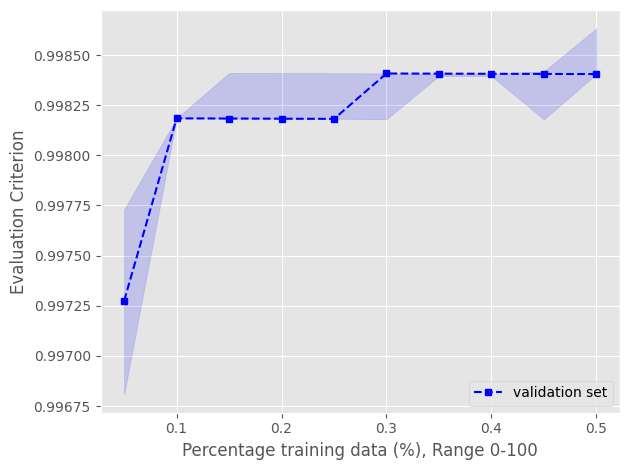

In [52]:
clf = LogisticRegression()

test_scores = []
train_sizes=np.linspace(5e-4,5e-3,10)

for size in train_sizes:
    cv = StratifiedShuffleSplit(n_splits=100,
                                train_size = size,
                                test_size = 1-size,
                               )
    test_scores.append(cross_val_score(estimator=clf,X=X,y=y,cv=cv,scoring=my_scorer))

plot_filled(np.array(test_scores), train_sizes*100, 'Percentage training data (%), Range 0-100')

___
*Enter you answer here (double click)*

It seems that the mean validation score plateaus around 0.2–0.3% of training data, and the confidence interval (5th–95th percentile) narrows there, indicating a good bias–variance tradeoff. With 58,725 total instances and assuming attacks are roughly 20–30% of the data, 0.2–0.3% of training data corresponds to approximately 23–53 positive examples (0.2% of 58,725 ≈ 117 total training examples × 20% ≈ 23 positive examples; 0.3% ≈ 176 total × 30% ≈ 53 positive examples). Below this range, variance is high (wide intervals) and performance is unstable. Above it, gains are minimal. Therefore, approximately 30–50 positive examples provide a good tradeoff: the mean score has stabilized (low bias) and the confidence interval is reasonably narrow (low variance), indicating reliable performance with manageable uncertainty. This suggests that daily retraining with only 3–5 examples would likely be too unreliable, as the variance would be too high for consistent performance.
___

___
<a id="stats"></a>
<a href="#top">Back to Top</a>

# Statistical Comparison
Now lets create a few different models and see if any of them have statistically better performances. 

We are creating three different classifiers below to compare to one another. For creating different training and testing splits, we are using stratified shuffle splits on the datasets. 



In [53]:
clf1 = LogisticRegression(C=100)
clf2 = LogisticRegression(C=1)
clf3 = LogisticRegression(C=0.1)

train_size = 0.003 # small training size
cv = StratifiedShuffleSplit(n_splits=10,train_size=train_size,test_size=1-train_size)

evals1 = cross_val_score(estimator=clf1,X=X,y=y,scoring=my_scorer,cv=cv)
evals2 = cross_val_score(estimator=clf2,X=X,y=y,scoring=my_scorer,cv=cv)
evals3 = cross_val_score(estimator=clf3,X=X,y=y,scoring=my_scorer,cv=cv)

**Question 7**: Given the code above, what statistical test is more appropriate for selecting confidence intervals, and **why**? Your options are:
- **A**: approximating the evaluation criterion as a binomial distribution and bounding by the variance (the first option we used in the flipped lecture video)
- **B**: approximating the bounds using the folds of the cross validation to get mean and variance (the second option we used in the flipped lecture video)
- **C**: Either are acceptable statistical tests for obtaining confidence intervals

*Enter you answer here (double click)*

*The reason that I think (A or B or C) is correct is because...*

**I think the B is correct.** Approximating bounds using the folds of cross-validation to get mean and variance. This is more appropriate than treating it as a binomial distribution because we have multiple independent evaluations (one per fold), the evaluation criterion (F1-score, accuracy, etc.) is a continuous score rather than a simple binary outcome, the t-distribution accounts for uncertainty in estimating the mean from a small sample (10 folds), and the binomial approximation would require treating each prediction as independent, which is invalid since predictions within a fold are correlated. Therefore, option B (using the fold-based mean and variance with t-distribution) is the correct statistical approach for confidence intervals in cross-validation. This method properly accounts for the sampling variability inherent in cross-validation and provides appropriate confidence bounds for comparing model performance
___

___
**Final Exercise:** With 95% confidence, perform the statistical test that you selected above. Is any model or set of models statistically the best performer(s)? Or can we not say if the models are different with greater than 95% confidence?

If you chose option A, use a multiplier of Z=1.96. The number of instances used in testing can be calculated from the variable `train_size`.

If you chose option B, use a multiplier of t=2.26 and k=10.

In [54]:
from scipy import stats
import numpy as np

# Calculate means and standard errors for each model
mean1 = np.mean(evals1)
mean2 = np.mean(evals2)
mean3 = np.mean(evals3)

std1 = np.std(evals1, ddof=1)  # sample standard deviation
std2 = np.std(evals2, ddof=1)
std3 = np.std(evals3, ddof=1)

se1 = std1 / np.sqrt(len(evals1))  # standard error
se2 = std2 / np.sqrt(len(evals2))
se3 = std3 / np.sqrt(len(evals3))

# t-value for 95% confidence, k-1=9 degrees of freedom
t_value = 2.26
k = 10

# Calculate confidence intervals
ci1_lower = mean1 - t_value * se1
ci1_upper = mean1 + t_value * se1

ci2_lower = mean2 - t_value * se2
ci2_upper = mean2 + t_value * se2

ci3_lower = mean3 - t_value * se3
ci3_upper = mean3 + t_value * se3

print(f'Model 1 (C=100): Mean = {mean1:.4f}, CI = [{ci1_lower:.4f}, {ci1_upper:.4f}]')
print(f'Model 2 (C=1):   Mean = {mean2:.4f}, CI = [{ci2_lower:.4f}, {ci2_upper:.4f}]')
print(f'Model 3 (C=0.1): Mean = {mean3:.4f}, CI = [{ci3_lower:.4f}, {ci3_upper:.4f}]')

# Check for statistical significance
# If confidence intervals overlap, models are not significantly different
if ci1_upper < ci2_lower or ci2_upper < ci1_lower:
    print('\nModel 1 and Model 2 are significantly different at 95% confidence')
else:
    print('\nModel 1 and Model 2 are NOT significantly different at 95% confidence')

if ci1_upper < ci3_lower or ci3_upper < ci1_lower:
    print('Model 1 and Model 3 are significantly different at 95% confidence')
else:
    print('Model 1 and Model 3 are NOT significantly different at 95% confidence')

if ci2_upper < ci3_lower or ci3_upper < ci2_lower:
    print('Model 2 and Model 3 are significantly different at 95% confidence')
else:
    print('Model 2 and Model 3 are NOT significantly different at 95% confidence')

# Determine best model
means = [mean1, mean2, mean3]
best_idx = np.argmax(means)
best_model = f'Model {best_idx + 1} (C={[100, 1, 0.1][best_idx]})'

# Check if best model is significantly better than others
best_is_significant = True
for i, mean in enumerate(means):
    if i != best_idx:
        ci_lower = [ci1_lower, ci2_lower, ci3_lower][i]
        ci_upper = [ci1_upper, ci2_upper, ci3_upper][i]
        best_ci_lower = [ci1_lower, ci2_lower, ci3_lower][best_idx]
        if ci_upper >= best_ci_lower:
            best_is_significant = False
            break

if best_is_significant:
    print(f'\n{best_model} has statistically the best performance with 95% confidence')
else:
    print(f'\nCannot conclude that any model is statistically the best with 95% confidence')
    print(f'However, {best_model} has the highest mean performance')

Model 1 (C=100): Mean = 0.9907, CI = [0.9739, 1.0076]
Model 2 (C=1):   Mean = 0.9984, CI = [0.9983, 0.9984]
Model 3 (C=0.1): Mean = 0.9965, CI = [0.9963, 0.9966]

Model 1 and Model 2 are NOT significantly different at 95% confidence
Model 1 and Model 3 are NOT significantly different at 95% confidence
Model 2 and Model 3 are significantly different at 95% confidence

Cannot conclude that any model is statistically the best with 95% confidence
However, Model 2 (C=1) has the highest mean performance


________________________________________________________________________________________________________

That's all! Please **save (make sure you saved!!!) and upload your rendered notebook** and please include **team member names** in the notebook submission.